<a href="https://colab.research.google.com/github/rajeshxdatascience/Car-Price-Prediction-ML/blob/main/02_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_parquet("/content/car_price_prediction.parquet")
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   km_driven                   3550 non-null   float64
 1   car_age                     3550 non-null   int64  
 2   log_price                   3550 non-null   float64
 3   brand_bmw                   3550 non-null   bool   
 4   brand_chevrolet             3550 non-null   bool   
 5   brand_datsun                3550 non-null   bool   
 6   brand_fiat                  3550 non-null   bool   
 7   brand_ford                  3550 non-null   bool   
 8   brand_honda                 3550 non-null   bool   
 9   brand_hyundai               3550 non-null   bool   
 10  brand_mahindra              3550 non-null   bool   
 11  brand_maruti                3550 non-null   bool   
 12  brand_mercedes-benz         3550 non-null   bool   
 13  brand_nissan                3550 

In [ ]:
df['km_driven'].sample(10)

,km_driven
2821,60000.0
2391,22000.0
1716,8000.0
2947,25000.0
101,110000.0
3203,98900.0
3321,68350.0
958,110000.0
2699,70000.0
2955,40000.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
X = df.drop('log_price',axis=1)
y = df['log_price']

X_train, X_test , y_train, y_test = train_test_split(X, y , test_size=0.2,random_state=42)

X_train = X_train.astype(float)

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 Score", r2_score(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

MAE 0.30584805786819597
MSE 0.14798027049277065
R2 Score 0.7840409786174871
RMSE 0.38468203817278845


In [ ]:
lr.coef_

array([-1.14429635e-06, -1.10126713e-01, -9.21715484e-02, -1.42203183e+00,
       -1.47240001e+00, -1.39699245e+00, -1.08386677e+00, -8.58860637e-01,
       -1.06161139e+00, -9.05299455e-01, -1.17546534e+00,  1.79677718e-01,
       -1.10999885e+00, -2.69780263e-01, -1.22541903e+00, -9.61028865e-01,
       -1.55627827e+00, -4.84598617e-01, -1.01224239e+00, -1.29552758e-01,
       -4.85570713e-02, -1.33309100e-01, -1.00093353e-01, -4.27962297e-01,
       -5.07472682e-01, -4.31770123e-01])

In [ ]:
lr.intercept_

np.float64(16.03629943305918)

Text(0.5, 1.0, 'Actual vs Predicted')

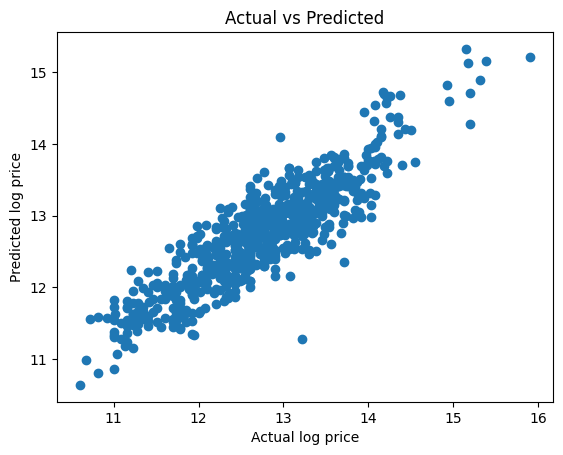

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
plt.title("Actual vs Predicted")

In [ ]:
X_test.shape

(710, 26)

In [ ]:
r2 = r2_score(y_test,y_pred)


In [ ]:
print("Adjusted R2 Score",1 - ((1 - r2)*(710-1))/(710-1-26))

Adjusted R2 Score 0.7758199909806711


Text(0, 0.5, 'Residuals')

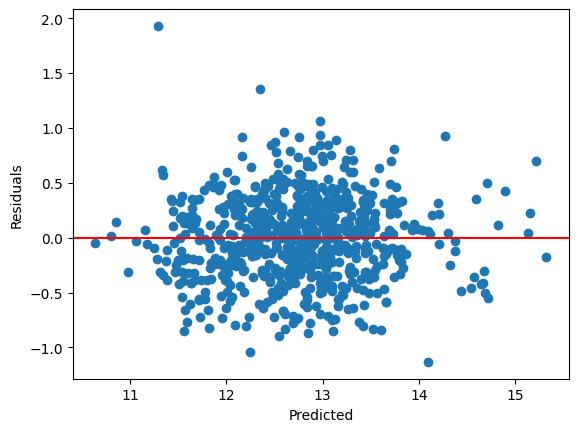

In [ ]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

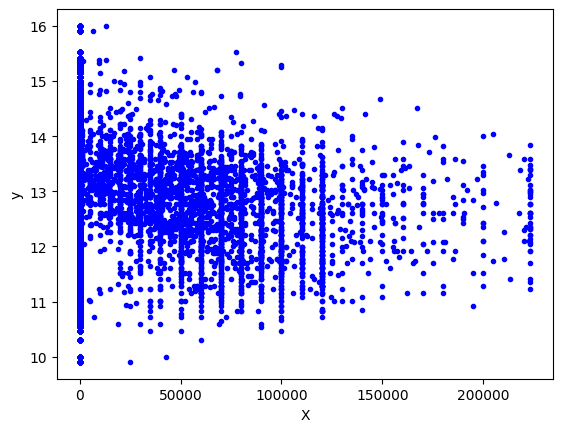

In [ ]:
plt.plot(X, y, 'b. ')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

Text(0.5, 1.0, 'Actual vs Predicted')

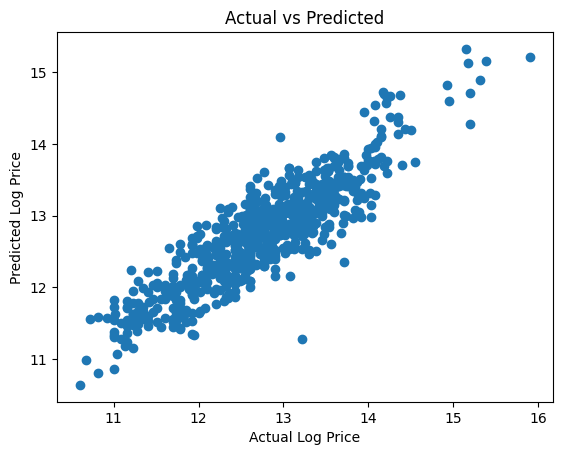

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted")

In [ ]:
df_numeric = df.astype(float)

condition_number = np.linalg.cond(df_numeric)
print("Condition Number:", condition_number)

Condition Number: 3527630.372070348


In [ ]:
import statsmodels.api as sm

# Constant add karna mat bhulna (Intercept ke liye)
X_train_sm = sm.add_constant(X_train.astype(float))
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     371.5
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:41:59   Log-Likelihood:                -1336.9
No. Observations:                2840   AIC:                             2728.
Df Residuals:                    2813   BIC:                             2889.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
from sklearn.preprocessing import StandardScaler

cols = X_train.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = X_train.astype(float)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Extract the independent variables (features) and target variable
X = df.drop('log_price', axis=1)
X = X.astype('float')

# Calculate the VIF for each feature
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,km_driven,5.723728
1,car_age,16.250102
2,brand_bmw,1.076820
3,brand_chevrolet,2.204947
4,brand_datsun,1.212525
5,brand_fiat,1.253402
6,brand_ford,2.347188
7,brand_honda,2.402161
8,brand_hyundai,5.605219
9,brand_mahindra,3.258398


In [ ]:
# Set the threshold for VIF
vif_threshold = 10

# Identify features with high VIF values
high_vif_features = vif[vif['VIF'] > vif_threshold]['Feature'].values

# Remove features with high VIF values from the dataset
df_filtered_vif = df.drop(high_vif_features, axis=1)

df_filtered_vif

,km_driven,log_price,brand_bmw,brand_chevrolet,brand_datsun,brand_fiat,brand_ford,brand_honda,brand_hyundai,brand_mahindra,...,brand_skoda,brand_tata,brand_toyota,brand_volkswagen,owner_fourth & above owner,owner_second owner,owner_third owner,seller_type_individual,fuel_other,fuel_petrol
0,70000.0,11.002100,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,50000.0,11.813030,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
2,100000.0,13.304685,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,46000.0,12.429216,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
4,141000.0,13.017003,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3545,170000.0,13.304685,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3546,80000.0,12.923910,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
3547,83000.0,11.608236,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
3548,90000.0,13.670485,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [ ]:
lasso.coef_

array([-0.        , -0.4363818 ,  0.        , -0.        , -0.        ,
       -0.        ,  0.        ,  0.        , -0.        ,  0.        ,
       -0.        ,  0.        ,  0.        ,  0.        , -0.        ,
        0.        , -0.0446063 ,  0.03050512,  0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.14217778, -0.        ,
       -0.13972171])

<Axes: >

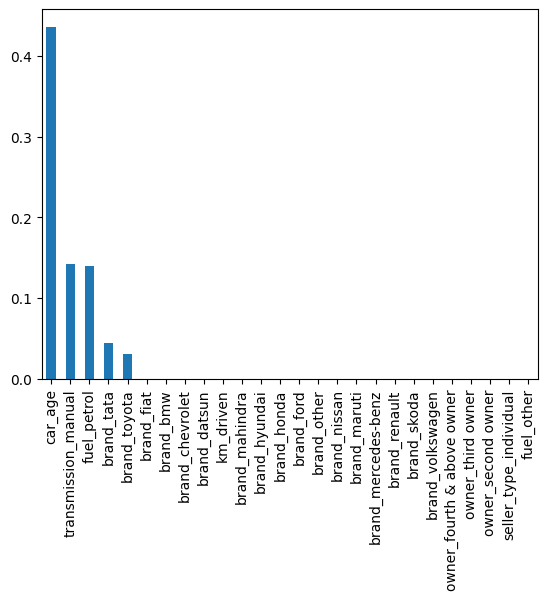

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = pd.Series(np.abs(lasso.coef_),index=cols)

x.sort_values(ascending=False).plot(kind='bar')

In [ ]:
X = df.drop('log_price',axis=1)
y = df['log_price']

X_train_scaled, X_test_scaled , y_train, y_test = train_test_split(X, y , test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)

In [ ]:
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 Score", r2_score(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

MAE 0.30584805786819597
MSE 0.14798027049277065
R2 Score 0.7840409786174871
RMSE 0.38468203817278845


In [ ]:
import statsmodels.api as sm

# Constant add karna mat bhulna (Intercept ke liye)
X_train_sm = sm.add_constant(X_train_scaled.astype(float))
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     371.5
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:42:03   Log-Likelihood:                -1336.9
No. Observations:                2840   AIC:                             2728.
Df Residuals:                    2813   BIC:                             2889.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [ ]:
X_train.shape

(2840, 26)

In [ ]:
y_train.shape

(2840,)

In [ ]:
# Check kijiye ki aapka scaler aur model dono 26 features par hi hain
print("Scaler features:", scaler.n_features_in_)
print("Model features:", lr.n_features_in_)

# Dono ka count 26 hona chahiye.

Scaler features: 26
Model features: 26


Text(0, 0.5, 'Residuals')

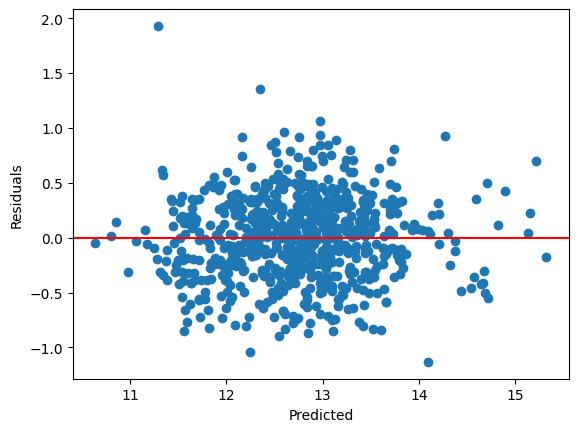

In [ ]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

Text(0.5, 1.0, 'Residuals Distribution (Histogram)')

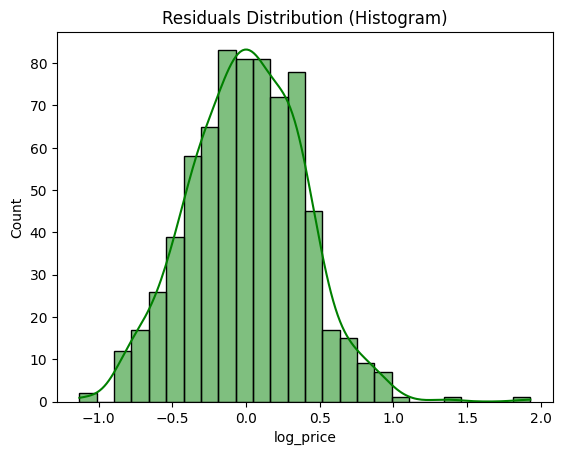

In [ ]:
import seaborn as sns

residuals = y_test - y_pred

sns.histplot(residuals, kde=True, color='green')
plt.title('Residuals Distribution (Histogram)')

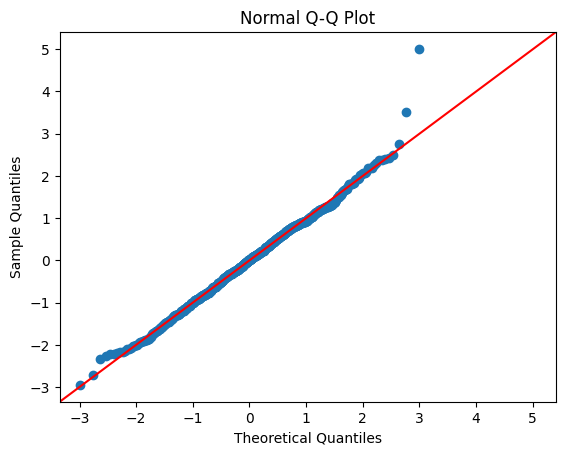

In [ ]:
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normal Q-Q Plot')
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)

print(ridge.score(X_test_scaled, y_test))

0.7815814069308508


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {"alpha":[0.01,0.1,1,10,50,100]}

ridge = Ridge()
grid = GridSearchCV(ridge, params, cv=5)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.01}
0.7645830091118108


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

print(rf.score(X_test, y_test))

0.7568705010303065


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pickle
import numpy as np

# 1. X aur y ko prepare karein
# Ensure karein X mein 26 features hain aur y log scale par hai
X_final = X.drop(columns=['const'], errors='ignore')
y_final = np.log(y) if y.mean() > 100 else y # Agar y already log nahi hai toh

# 2. Scaler Fit & Transform
scaler_prod = StandardScaler()
X_scaled = scaler_prod.fit_transform(X_final)

# 3. Model Training
model_prod = LinearRegression()
model_prod.fit(X_scaled, y_final)

# 4. Save Everything
pickle.dump(model_prod, open('car_price_model.pkl', 'wb'))
pickle.dump(scaler_prod, open('scaler.pkl', 'wb'))
pickle.dump(list(X_final.columns), open('columns.pkl', 'wb'))

print("✅ Files Saved! Inhe download karke VS Code mein replace kar dein.")

✅ Files Saved! Inhe download karke VS Code mein replace kar dein.
